# Head-to-head: routing strategies on the same test prompts

Everything the earlier notebooks produced meets here, on the identical 2,434 held-out
test prompts. The contenders: the two fixed baselines (always-cheapest,
always-strongest), every individual model as a fixed strategy for context, the tuned
logistic and random forest routers from notebook 03, the regressor-derived router from
notebook 04, the oracle label as the ceiling, and OpenRouter, the commercial router
whose per-prompt results ship inside LLMRouterBench as a reference baseline. OpenRouter
has no tau2 results in the release, but that ends up costing nothing here: tau2 already
fell out of the modeling set at the label step (gpt-5-chat was never run on it, so no
tau2 prompt has the full 13-model menu), and OpenRouter covers every remaining test
prompt.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

proc = Path("..") / "data" / "processed"
long_df = pd.read_parquet(proc / "records_long.parquet")
core = long_df[~long_df.is_reference]
openrouter = long_df[long_df.is_reference]
model_df = pd.read_parquet(proc / "prompts_features_labels_tau100.parquet")
router_preds = pd.read_parquet(proc / "router_test_predictions.parquet")
reg_picks = pd.read_parquet(proc / "regressor_test_picks.parquet")

train_df, test_df = train_test_split(
    model_df, test_size=0.2, random_state=42, stratify=model_df.dataset)
test_rows = core[core.prompt_id.isin(test_df.prompt_id)]
lookup = test_rows.set_index(["prompt_id", "model"])[["cost", "score"]]

def outcome(picks):
    got = lookup.loc[list(zip(picks.index, picks.values, strict=True))]
    return got.cost.mean(), got.score.mean()

# every fixed single-model strategy, for context on the chart
fixed = test_rows.groupby("model").agg(cost=("cost", "mean"),
                                       score=("score", "mean"))

cheapest = fixed.cost.idxmin()
strongest = fixed.score.idxmax()
strategies = {
    f"always cheapest ({cheapest})": pd.Series(cheapest, index=test_df.prompt_id),
    f"always strongest ({strongest})": pd.Series(strongest, index=test_df.prompt_id),
    "logistic router (tuned)": router_preds.set_index("prompt_id").logistic_tuned,
    "random forest router (tuned)": router_preds.set_index(
        "prompt_id").random_forest_tuned,
    "regressor-derived router": reg_picks.set_index("prompt_id").regressor_routing,
    "oracle label": test_df.set_index("prompt_id").label,
}
rows = [{"strategy": name, "mean cost (USD)": outcome(p)[0],
         "mean score": outcome(p)[1]} for name, p in strategies.items()]

# openrouter: reference router, evaluated on the test prompts it covers
or_test = openrouter[openrouter.prompt_id.isin(test_df.prompt_id)]
rows.append({"strategy": f"OpenRouter (n={or_test.prompt_id.nunique():,})",
             "mean cost (USD)": or_test.cost.mean(),
             "mean score": or_test.score.mean()})
scoreboard = pd.DataFrame(rows).set_index("strategy")
scoreboard.round(4)

,mean cost (USD),mean score
strategy,,
always cheapest (deepseek-v3-0324),0.0008,0.4287
always strongest (gemini-2.5-pro),0.0615,0.5968
logistic router (tuned),0.0115,0.5637
random forest router (tuned),0.0073,0.5362
regressor-derived router,0.0006,0.5129
oracle label,0.0055,0.8215
"OpenRouter (n=2,434)",0.0225,0.4953


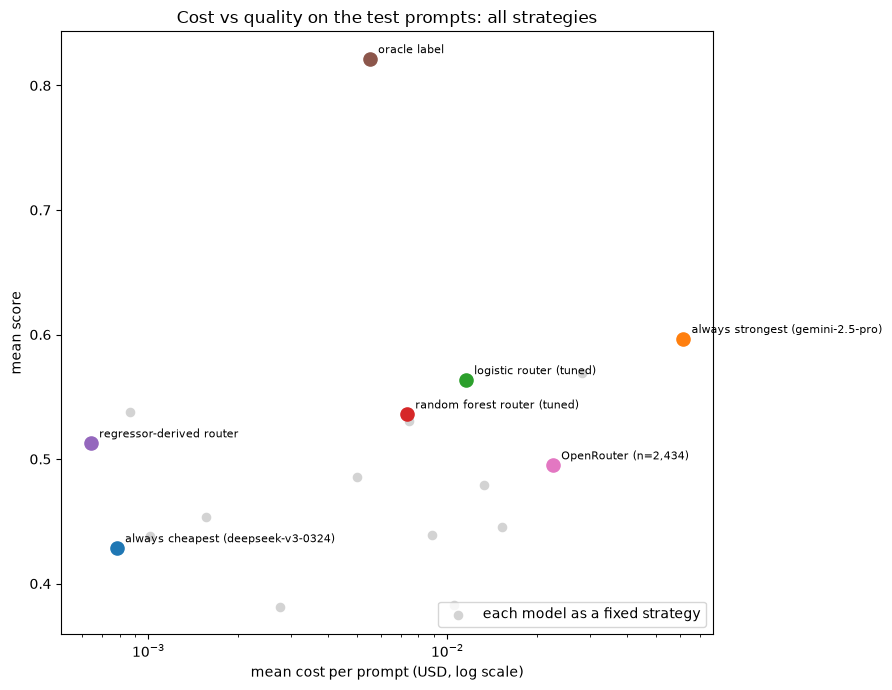

In [2]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(fixed.cost, fixed.score, color="lightgray", s=35, zorder=1,
           label="each model as a fixed strategy")
for name, row in scoreboard.iterrows():
    ax.scatter(row["mean cost (USD)"], row["mean score"], s=90, zorder=2)
    ax.annotate(name, (row["mean cost (USD)"], row["mean score"]), fontsize=8,
                xytext=(6, 4), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("mean cost per prompt (USD, log scale)")
ax.set_ylabel("mean score")
ax.set_title("Cost vs quality on the test prompts: all strategies")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

The frontier tells the story better than the table. The regressor-derived router
($0.0006, 0.513) is the cheapest point on the chart, cheaper than any single model,
because no one model is the cheapest on every prompt. The fixed qwen3-235b-a22b-2507
dot ($0.0009, 0.538) is the best-value single model, and it quietly dominates my tuned
forest router ($0.0073, 0.536). I did not expect that and I kept it in: a router has to
beat the best single model to justify existing, and on quality only the logistic router
(0.564) and always-strongest (0.597) clear qwen's bar, both at a much higher price.
OpenRouter ($0.0225, 0.495) sits well inside the frontier, beaten on both axes by three
of my strategies. The oracle ($0.0055, 0.82) shows the headroom: the best achievable
quality is not expensive, it just requires knowing per prompt which model to trust,
which is the part nobody's features are good enough to fully deliver.

## Threshold sensitivity, this time on the whole comparison

Notebook 02 showed the 0.5 threshold relabels 2.1 percent of prompts. The sharper
question is whether any strategy's position on the chart moves. I retrained both tuned
routers on the threshold-0.5 labels with the same hyperparameters the searches picked
(logistic C=10, forest with 300 unrestricted trees) and rebuilt the scoreboard.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

model_df_050 = pd.read_parquet(proc / "prompts_features_labels_tau050.parquet")
tr50 = model_df_050[model_df_050.prompt_id.isin(train_df.prompt_id)]
te50 = model_df_050[model_df_050.prompt_id.isin(test_df.prompt_id)]
feature_cols = ["dataset", "query_chars", "med_prompt_tokens"]

def make_prep():
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["dataset"]),
        ("num", StandardScaler(), ["query_chars", "med_prompt_tokens"]),
    ])

variants = {
    "logistic": LogisticRegression(max_iter=3000, C=10),
    "random forest": RandomForestClassifier(n_estimators=300, random_state=42),
}
sens_rows = []
for name, clf in variants.items():
    pipe = Pipeline([("prep", make_prep()), ("clf", clf)])
    pipe.fit(tr50[feature_cols], tr50.label)
    picks = pd.Series(pipe.predict(te50[feature_cols]), index=te50.prompt_id)
    cost, score = outcome(picks)
    base = scoreboard.loc[f"{name} router (tuned)"] if name == "logistic"         else scoreboard.loc["random forest router (tuned)"]
    sens_rows.append({
        "router": name,
        "cost @ threshold 1.0": base["mean cost (USD)"],
        "cost @ threshold 0.5": cost,
        "score @ threshold 1.0": base["mean score"],
        "score @ threshold 0.5": score,
    })
oracle50_cost, oracle50_score = outcome(te50.set_index("prompt_id").label)
sens_rows.append({
    "router": "oracle label",
    "cost @ threshold 1.0": scoreboard.loc["oracle label", "mean cost (USD)"],
    "cost @ threshold 0.5": oracle50_cost,
    "score @ threshold 1.0": scoreboard.loc["oracle label", "mean score"],
    "score @ threshold 0.5": oracle50_score,
})
pd.DataFrame(sens_rows).set_index("router").round(4)

,cost @ threshold 1.0,cost @ threshold 0.5,score @ threshold 1.0,score @ threshold 0.5
router,,,,
logistic,0.0115,0.0115,0.5637,0.5637
random forest,0.0073,0.0070,0.5362,0.5343
oracle label,0.0055,0.0055,0.8215,0.8127


The comparison held still. The logistic router did not move at this precision, the
forest shifted by three hundredths of a cent and two thousandths of a score point, and
the oracle ceiling dipped from 0.8215 to 0.8127 because accepting arenahard draws as
capable lets the ceiling settle for a few cheaper draws. No ranking changes, so the
threshold-1.0 results carry the report.

## Where this sits against the published results

LLMRouterBench ships with ten routing baselines, and the paper's Performance-Cost
tables give my numbers some outside context. Their reported ceiling is Avengers-Pro,
which sits essentially on the Pareto frontier of their benchmark (near-zero average
Pareto distance), and their top methods reach up to a 4 percent performance gain over
the best single model or a 31.7 percent cost saving while holding its accuracy. Their
tables also show the pattern my chart reproduces from the outside: several routers,
including the commercial OpenRouter, fail to beat the best single model on the
performance-cost tradeoff. On my test prompts OpenRouter lands well inside the
frontier, costlier and lower-scoring than a fixed diet of qwen3-235b-a22b-2507, and my
trained routers beat OpenRouter on both axes while my regressor-derived router
undercuts even the always-cheapest baseline. Against the paper's ceiling my routers
stay honest students rather than record-setters: none of them clears the best single
model's score the way Avengers-Pro does, they buy their savings by accepting a small
quality discount instead. Closing that last gap is exactly what the published
state of the art does with heavier machinery (query embeddings and clustered expertise
profiles) than my deliberately light feature set.